In [1]:
import os

train_dir = 'data/train'
valid_dir = 'data/valid'

class_names = os.listdir(train_dir)
print(f"Number of disease classes: {len(class_names)}")
print("\nFirst 10 class names:")
for name in class_names[:10]:
    print(" -", name)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/train'

In [2]:
import os

for item in os.listdir('data'):
    print(item)

New Plant Diseases Dataset(Augmented)
test


In [3]:
import os

nested_path = 'data/New Plant Diseases Dataset(Augmented)'
for item in os.listdir(nested_path):
    print(item)

New Plant Diseases Dataset(Augmented)


In [4]:
import os

train_dir = None
valid_dir = None

for root, dirs, files in os.walk('data'):
    if os.path.basename(root).lower() == 'train':
        train_dir = root
    if os.path.basename(root).lower() == 'valid':
        valid_dir = root

print("Train folder found at:", train_dir)
print("Valid folder found at:", valid_dir)

Train folder found at: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
Valid folder found at: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid


In [5]:
class_names = sorted(os.listdir(train_dir))
print(f"Number of disease classes: {len(class_names)}")
print("\nFirst 10 class names:")
for name in class_names[:10]:
    print(" -", name)

Number of disease classes: 38

First 10 class names:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___Cedar_apple_rust
 - Apple___healthy
 - Blueberry___healthy
 - Cherry_(including_sour)___Powdery_mildew
 - Cherry_(including_sour)___healthy
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___Northern_Leaf_Blight


In [6]:
class_counts = {}
for name in class_names:
    class_path = os.path.join(train_dir, name)
    class_counts[name] = len(os.listdir(class_path))

for name, count in list(class_counts.items())[:10]:
    print(f"{name}: {count} images")

Apple___Apple_scab: 2016 images
Apple___Black_rot: 1987 images
Apple___Cedar_apple_rust: 1760 images
Apple___healthy: 2008 images
Blueberry___healthy: 1816 images
Cherry_(including_sour)___Powdery_mildew: 1683 images
Cherry_(including_sour)___healthy: 1826 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
Corn_(maize)___Common_rust_: 1907 images
Corn_(maize)___Northern_Leaf_Blight: 1908 images


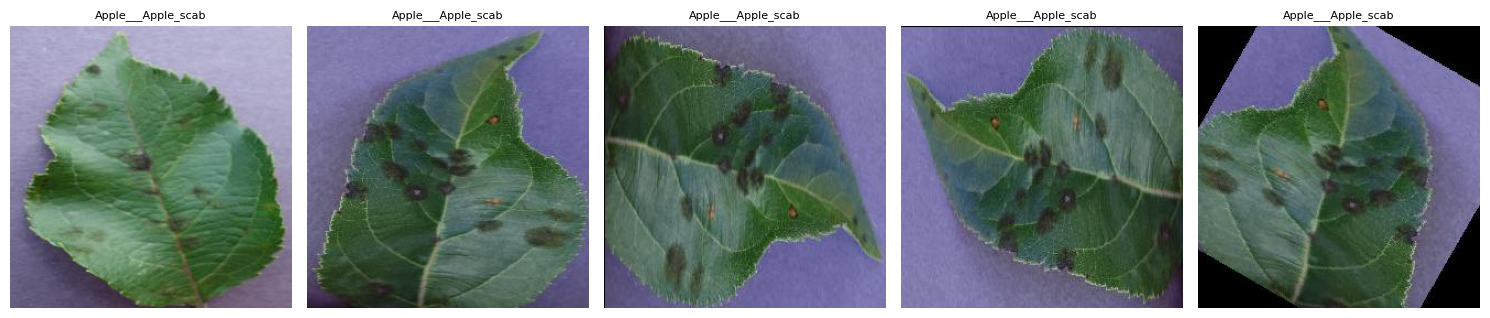

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_class = class_names[0]
sample_folder = os.path.join(train_dir, sample_class)
sample_images = os.listdir(sample_folder)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(sample_folder, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(sample_class, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
sample_img_path = os.path.join(sample_folder, sample_images[0])
img = Image.open(sample_img_path)
print("Image size (width x height):", img.size)
print("Image format:", img.format)
print("Color mode:", img.mode)

Image size (width x height): (256, 256)
Image format: JPEG
Color mode: RGB


In [9]:
print(f"""
DATA EXPLORATION SUMMARY
-------------------------
Train directory: {train_dir}
Valid directory: {valid_dir}
Total classes: {len(class_names)}
Sample image size: {img.size}
""")


DATA EXPLORATION SUMMARY
-------------------------
Train directory: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
Valid directory: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid
Total classes: 38
Sample image size: (256, 256)



In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(30, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,425,822 (9.25 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
print("Classes found by train_generator:", train_generator.num_classes)
print("Classes found by valid_generator:", valid_generator.num_classes)
print("\nAll class names:")
for name in train_generator.class_indices:
    print(" -", name)

Classes found by train_generator: 38
Classes found by valid_generator: 38

All class names:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___Cedar_apple_rust
 - Apple___healthy
 - Blueberry___healthy
 - Cherry_(including_sour)___Powdery_mildew
 - Cherry_(including_sour)___healthy
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___Northern_Leaf_Blight
 - Corn_(maize)___healthy
 - Grape___Black_rot
 - Grape___Esca_(Black_Measles)
 - Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 - Grape___healthy
 - Orange___Haunglongbing_(Citrus_greening)
 - Peach___Bacterial_spot
 - Peach___healthy
 - Pepper,_bell___Bacterial_spot
 - Pepper,_bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Raspberry___healthy
 - Soybean___healthy
 - Squash___Powdery_mildew
 - Strawberry___Leaf_scorch
 - Strawberry___healthy
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomat

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

NUM_CLASSES = train_generator.num_classes

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model rebuilt with {NUM_CLASSES} output classes.")

Model rebuilt with 38 output classes.


In [17]:
history = model.fit(
    train_generator,
    steps_per_epoch=20,
    validation_data=valid_generator,
    validation_steps=10,
    epochs=1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1016 - loss: 3.4231 - val_accuracy: 0.3719 - val_loss: 2.7843


In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [19]:
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = valid_generator.samples // BATCH_SIZE

print("Steps per epoch (training):", steps_per_epoch)
print("Validation steps:", validation_steps)

Steps per epoch (training): 2196
Validation steps: 549


In [20]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.7631 - loss: 0.8164
Epoch 1: val_accuracy improved from None to 0.92993, saving model to best_model.keras
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 2607s 1s/step - accuracy: 0.8450 - loss: 0.5033 - val_accuracy: 0.9299 - val_loss: 0.2092
Epoch 2/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 34:02 930ms/step - accuracy: 0.9688 - loss: 0.1107

C:\Users\MANYA BHATT\anaconda3\envs\cropcare\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.92993
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 463s 210ms/step - accuracy: 0.9688 - loss: 0.1107 - val_accuracy: 0.9288 - val_loss: 0.2114
Epoch 3/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.9119 - loss: 0.2645
Epoch 3: val_accuracy improved from 0.92993 to 0.94046, saving model to best_model.keras
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1952s 883ms/step - accuracy: 0.9139 - loss: 0.2586 - val_accuracy: 0.9405 - val_loss: 0.1757
Epoch 4/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 19:06 523ms/step - accuracy: 0.9375 - loss: 0.2257
Epoch 4: val_accuracy improved from 0.94046 to 0.94057, saving model to best_model.keras
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9375 - loss: 0.2257 - val_accuracy: 0.9406 - val_loss: 0.1752
Epoch 5/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.9284 - loss: 0.2106
Epoch 5: val_accuracy improved from 0.94057 to 0.94832, saving model to best_model.keras
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1689s 7

In [21]:
import os
print("best_model.keras exists:", os.path.exists('best_model.keras'))
print("File size (MB):", round(os.path.getsize('best_model.keras') / (1024*1024), 2))

best_model.keras exists: True
File size (MB): 11.11


In [22]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')
print("Model loaded successfully, ready to resume training.")

Model loaded successfully, ready to resume training.


In [23]:
history_part2 = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9473 - loss: 0.1478
Epoch 1: val_accuracy improved from 0.95475 to 0.95738, saving model to best_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1582s 715ms/step - accuracy: 0.9468 - loss: 0.1497 - val_accuracy: 0.9574 - val_loss: 0.1236
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9529 - loss: 0.1356
Epoch 2: val_accuracy did not improve from 0.95738
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1474s 671ms/step - accuracy: 0.9513 - loss: 0.1409 - val_accuracy: 0.9567 - val_loss: 0.1309
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9551 - loss: 0.1281
Epoch 3: val_accuracy improved from 0.95738 to 0.95760, saving model to best_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1668s 759ms/step - accuracy: 0.9537 - loss: 0.1324 - val_accuracy: 0.9576 - val_loss: 0.1355
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.9588 - loss: 0.1176
Epoch 4: val_accuracy improved from 0.95760

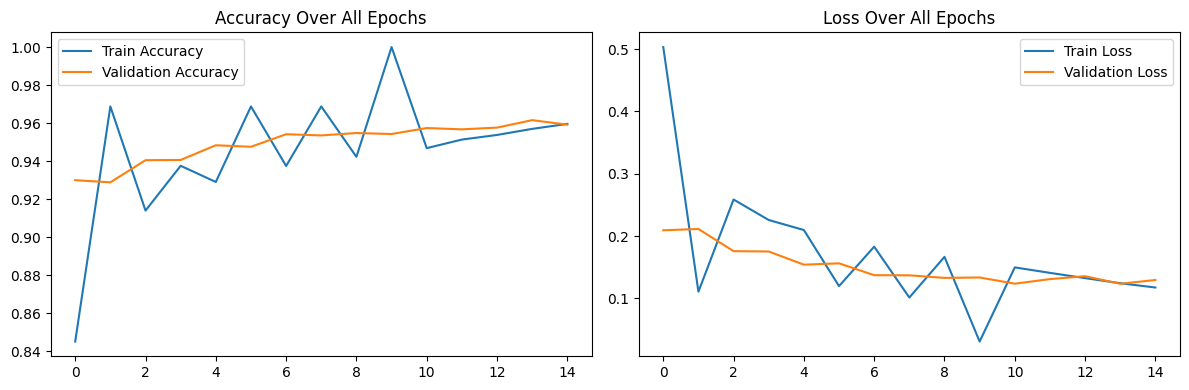

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + history_part2.history['accuracy']
val_acc = history.history['val_accuracy'] + history_part2.history['val_accuracy']
loss = history.history['loss'] + history_part2.history['loss']
val_loss = history.history['val_loss'] + history_part2.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy Over All Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Over All Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
print("Final training accuracy:", round(acc[-1] * 100, 2), "%")
print("Final validation accuracy:", round(val_acc[-1] * 100, 2), "%")

Final training accuracy: 95.96 %
Final validation accuracy: 95.91 %


In [26]:
import json

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

with open('class_names.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved class_names.json with", len(idx_to_class), "classes")
print("\nExample mapping:")
for i in range(3):
    print(i, "->", idx_to_class[i])

Saved class_names.json with 38 classes

Example mapping:
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust


In [27]:
import random

test_class = random.choice(class_names)
test_folder = os.path.join(valid_dir, test_class)
test_image_name = random.choice(os.listdir(test_folder))
test_image_path = os.path.join(test_folder, test_image_name)

print("True label (actual disease):", test_class)
print("Test image path:", test_image_path)

True label (actual disease): Orange___Haunglongbing_(Citrus_greening)
Test image path: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid\Orange___Haunglongbing_(Citrus_greening)\c6cad470-8a78-4755-82f9-a40dc18458e5___CREC_HLB 7721.JPG


In [28]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)
predicted_index = np.argmax(prediction[0])
predicted_class = idx_to_class[predicted_index]
confidence = round(float(np.max(prediction[0])) * 100, 2)

print("Predicted disease:", predicted_class)
print("Confidence:", confidence, "%")
print("Actual disease was:", test_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted disease: Orange___Haunglongbing_(Citrus_greening)
Confidence: 99.97 %
Actual disease was: Orange___Haunglongbing_(Citrus_greening)
